<a href="https://colab.research.google.com/github/agneswanjik/SPS-2471-SCIII-2023-BAST-/blob/main/Python_Data_Analysis_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#1. Import Required Libraries
# Data manipulation
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [3]:
#
# Upload datasets from local computer into Google Colab
from google.colab import files
uploaded = files.upload()

Saving FastBuy_2023-2024.csv to FastBuy_2023-2024.csv
Saving FastBuy_2024-2025.xlsx to FastBuy_2024-2025.xlsx


In [4]:
#2. Load the Datasets
# Load CSV dataset
df1 = pd.read_csv('FastBuy_2023-2024.csv')

# Load Excel dataset
df2 = pd.read_excel('FastBuy_2024-2025.xlsx')

# Preview datasets
print("CSV Dataset Preview")
display(df1.head())

print("Excel Dataset Preview")
display(df2.head())

CSV Dataset Preview


,CustomerID,Age,Gender,AnnualIncome,SpendingScore,PurchaseHistory,Location,PurchaseDate,PreferredDevice,PaymentMethod,Segment
0,CUST00358,25,F,41.288 K,79,Sports,New York,01/09/2023,Tablet,Credit Card,Budget
1,CUST00998,62,Female,75922,27,Home Decor,Los Angeles,02/09/2023,Mobile,Credit Card,Budget
2,CUST00466,21,Male,108397,22,Fashion,Chicago,02/09/2023,Tablet,Credit Card,Budget
3,CUST00577,48,Male,123674,91,Home Decor,New York,02/09/2023,Mobile,Credit Card,Premium
4,CUST00210,41,Male,56444,42,Electronics,New York,04/09/2023,Tablet,Debit Card,Budget


Excel Dataset Preview


,CustomerID,Age,Gender,AnnualIncome,SpendingScore,PurchaseHistory,Location,PurchaseDate,PreferredDevice,PaymentMethod,Segment
0,CUST00185,61,Female,148386,53,Fashion,New York,2024-09-01,Tablet,Gift Card,Standard
1,CUST00337,50,Female,122215,18,Home Decor,Chicago,2024-09-01,Desktop,Credit Card,Budget
2,CUST00945,59,Female,76549,96,Electronics,Houston,2024-09-01,Tablet,PayPal,Standard
3,CUST00700,69,Male,29108,8,Home Decor,Houston,2024-09-02,Desktop,PayPal,Budget
4,CUST00876,38,Male,61621,51,Sports,Seattle,2024-09-02,Mobile,Credit Card,Standard


In [5]:
#3. Combine Both Datasets
# Merge both datasets
df = pd.concat([df1, df2], ignore_index=True)

print("Combined dataset shape:", df.shape)

# Preview combined data
df.head()

Combined dataset shape: (1000, 11)


,CustomerID,Age,Gender,AnnualIncome,SpendingScore,PurchaseHistory,Location,PurchaseDate,PreferredDevice,PaymentMethod,Segment
0,CUST00358,25,F,41.288 K,79,Sports,New York,01/09/2023,Tablet,Credit Card,Budget
1,CUST00998,62,Female,75922,27,Home Decor,Los Angeles,02/09/2023,Mobile,Credit Card,Budget
2,CUST00466,21,Male,108397,22,Fashion,Chicago,02/09/2023,Tablet,Credit Card,Budget
3,CUST00577,48,Male,123674,91,Home Decor,New York,02/09/2023,Mobile,Credit Card,Premium
4,CUST00210,41,Male,56444,42,Electronics,New York,04/09/2023,Tablet,Debit Card,Budget


In [6]:
#4. Basic Data Exploration
# Dataset information
df.info()

# Summary statistics
df.describe()

# Check missing values
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   CustomerID       1000 non-null   object
 1   Age              1000 non-null   int64 
 2   Gender           1000 non-null   object
 3   AnnualIncome     1000 non-null   object
 4   SpendingScore    1000 non-null   int64 
 5   PurchaseHistory  1000 non-null   object
 6   Location         1000 non-null   object
 7   PurchaseDate     1000 non-null   object
 8   PreferredDevice  1000 non-null   object
 9   PaymentMethod    1000 non-null   object
 10  Segment          1000 non-null   object
dtypes: int64(2), object(9)
memory usage: 86.1+ KB


,0
CustomerID,0
Age,0
Gender,0
AnnualIncome,0
SpendingScore,0
PurchaseHistory,0
Location,0
PurchaseDate,0
PreferredDevice,0
PaymentMethod,0


In [7]:
#5. Data Cleaning
#Remove duplicates
df.drop_duplicates(inplace=True)

In [8]:
# Handle Missing Values
# Preprocess 'AnnualIncome' to convert 'K' values to numeric and then to float
df['AnnualIncome'] = df['AnnualIncome'].astype(str).str.replace(' K', '').astype(float) * 1000

# Fill numeric missing values with median
df['Age'].fillna(df['Age'].median(), inplace=True)
df['AnnualIncome'].fillna(df['AnnualIncome'].median(), inplace=True)
df['SpendingScore'].fillna(df['SpendingScore'].median(), inplace=True)

# Fill categorical missing values with mode
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
df['PaymentMethod'].fillna(df['PaymentMethod'].mode()[0], inplace=True)
df['PreferredDevice'].fillna(df['PreferredDevice'].mode()[0], inplace=True)
df['PurchaseHistory'].fillna(df['PurchaseHistory'].mode()[0], inplace=True)
df['Location'].fillna(df['Location'].mode()[0], inplace=True)

In [9]:
#Convert PurchaseDate to Date Format
df['PurchaseDate'] = pd.to_datetime(df['PurchaseDate'], errors='coerce')

In [10]:
#6. Exploratory Data Analysis (EDA)
# Average Annual Income
avg_income = df['AnnualIncome'].mean()
print("Average Annual Income:", avg_income)

Average Annual Income: 86956307.544


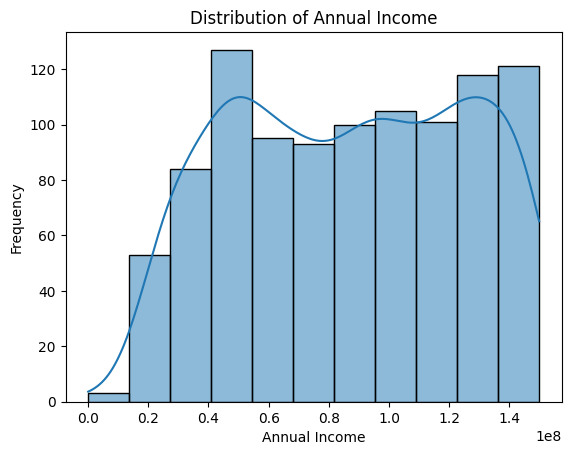

In [11]:
#Distribution of Annual Income
plt.figure()
sns.histplot(df['AnnualIncome'], kde=True)
plt.title("Distribution of Annual Income")
plt.xlabel("Annual Income")
plt.ylabel("Frequency")
plt.show()

PaymentMethod
Credit Card    50.512821
Debit Card     47.207692
Gift Card      48.916318
PayPal         48.842697
Name: SpendingScore, dtype: float64


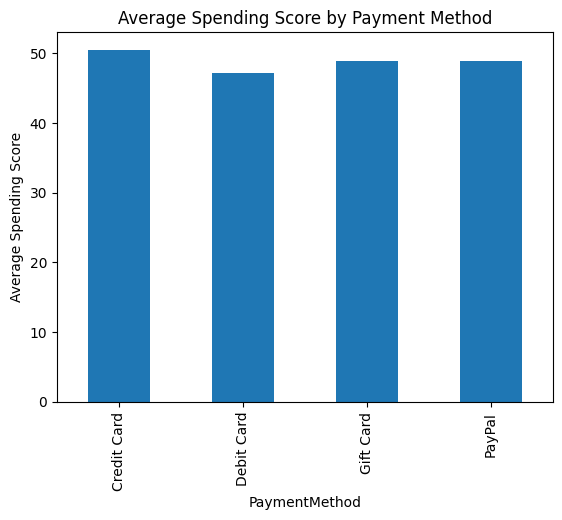

In [12]:
#Average Spending Score by Payment Method

avg_spending_payment = df.groupby('PaymentMethod')['SpendingScore'].mean()
print(avg_spending_payment)

avg_spending_payment.plot(kind='bar')
plt.title("Average Spending Score by Payment Method")
plt.ylabel("Average Spending Score")
plt.show()

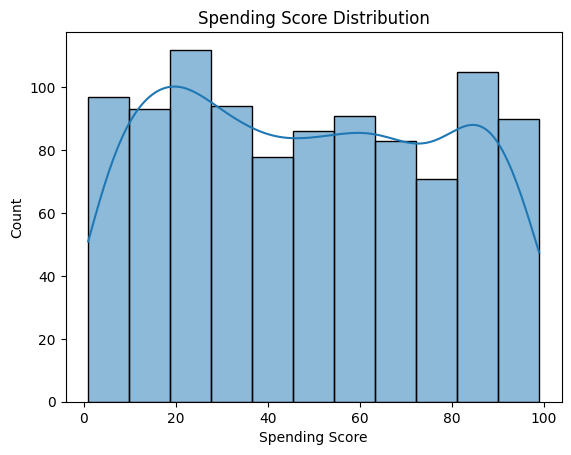

In [13]:
#Distribution of Spending Score
plt.figure()
sns.histplot(df['SpendingScore'], kde=True)
plt.title("Spending Score Distribution")
plt.xlabel("Spending Score")
plt.show()

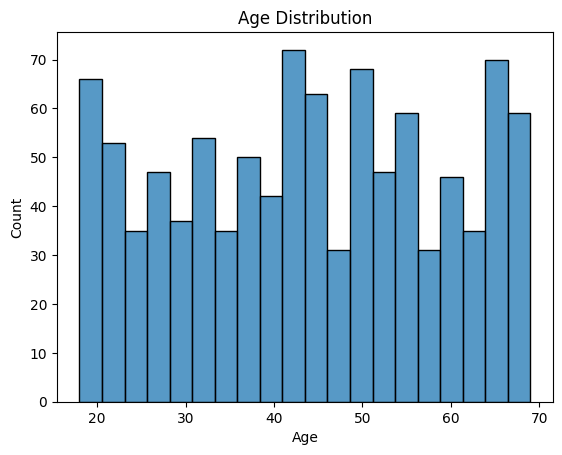

In [14]:
#Age Distribution
plt.figure()
sns.histplot(df['Age'], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.show()

PaymentMethod
PayPal         267
Debit Card     260
Gift Card      239
Credit Card    234
Name: count, dtype: int64


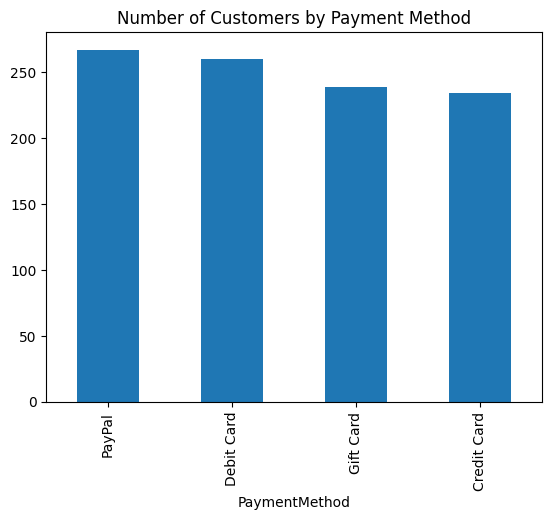

In [15]:
#Payment Method Count
payment_counts = df['PaymentMethod'].value_counts()
print(payment_counts)

payment_counts.plot(kind='bar')
plt.title("Number of Customers by Payment Method")
plt.show()

PreferredDevice
Mobile     345
Desktop    329
Tablet     326
Name: count, dtype: int64


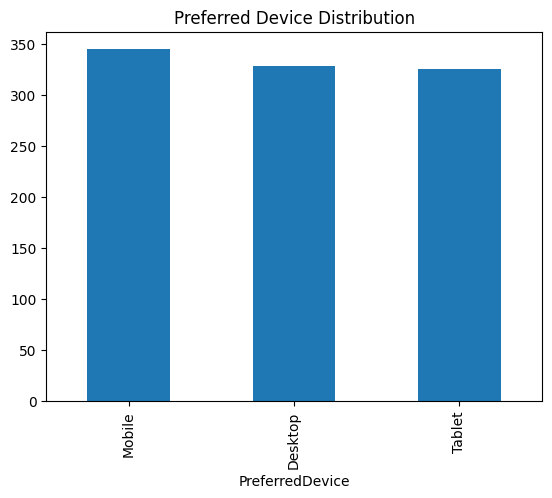

In [16]:
#Most Common Preferred Device
device_counts = df['PreferredDevice'].value_counts()

print(device_counts)

device_counts.plot(kind='bar')
plt.title("Preferred Device Distribution")
plt.show()

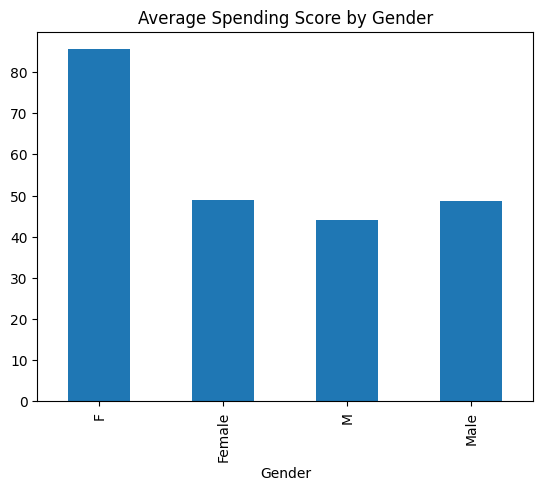

In [17]:
#Optional EDA
#Average Spending Score by Gender
gender_spending = df.groupby('Gender')['SpendingScore'].mean()

gender_spending.plot(kind='bar')
plt.title("Average Spending Score by Gender")
plt.show()

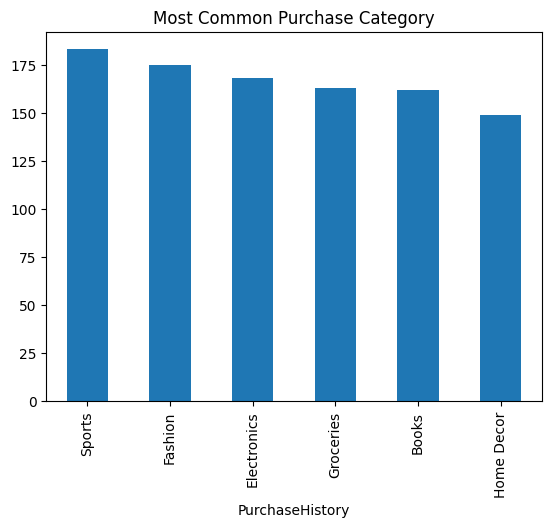

In [18]:
#Most Common Purchase History
purchase_counts = df['PurchaseHistory'].value_counts()

purchase_counts.plot(kind='bar')
plt.title("Most Common Purchase Category")
plt.show()

In [19]:
#7. Data Preparation for Machine Learning
#Encode categorical variables
label_encoder = LabelEncoder()

categorical_columns = [
    'Gender',
    'PurchaseHistory',
    'Location',
    'PreferredDevice',
    'PaymentMethod',
    'Segment'
]

for col in categorical_columns:
    df[col] = label_encoder.fit_transform(df[col])

In [20]:
#Select Features and Target
X = df.drop(['Segment','CustomerID','PurchaseDate'], axis=1)

y = df['Segment']

In [21]:
#8. Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

log_model = LogisticRegression()

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

log_accuracy = accuracy_score(y_test, y_pred_log)

print("Logistic Regression Accuracy:", log_accuracy)

Logistic Regression Accuracy: 0.64


In [22]:
#9. Model 1 — Logistic Regression
log_model = LogisticRegression()

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

log_accuracy = accuracy_score(y_test, y_pred_log)

print("Logistic Regression Accuracy:", log_accuracy)

Logistic Regression Accuracy: 0.64


In [23]:
#10. Model 2 — Random Forest
rf_model = RandomForestClassifier(n_estimators=100)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.97


In [24]:
#11. Model Evaluation
#Logistic Regression Report
print("Logistic Regression Classification Report")

print(classification_report(y_test, y_pred_log))

Logistic Regression Classification Report
              precision    recall  f1-score   support

           0       0.68      0.85      0.76       110
           1       0.00      0.00      0.00        20
           2       0.56      0.50      0.53        70

    accuracy                           0.64       200
   macro avg       0.41      0.45      0.43       200
weighted avg       0.57      0.64      0.60       200



In [25]:
#Random Forest Report
print("Random Forest Classification Report")

print(classification_report(y_test, y_pred_rf))

Random Forest Classification Report
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       110
           1       1.00      0.80      0.89        20
           2       0.94      0.97      0.96        70

    accuracy                           0.97       200
   macro avg       0.98      0.92      0.95       200
weighted avg       0.97      0.97      0.97       200



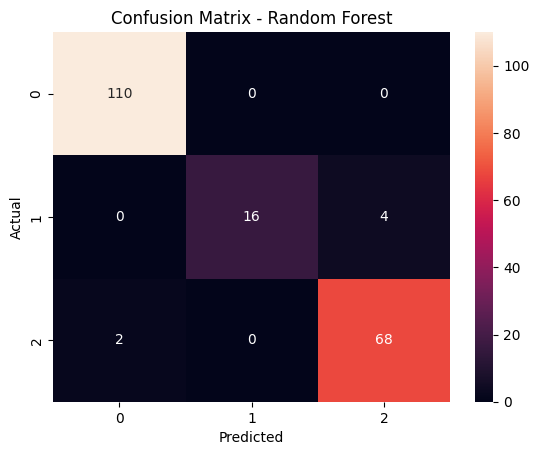

In [26]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

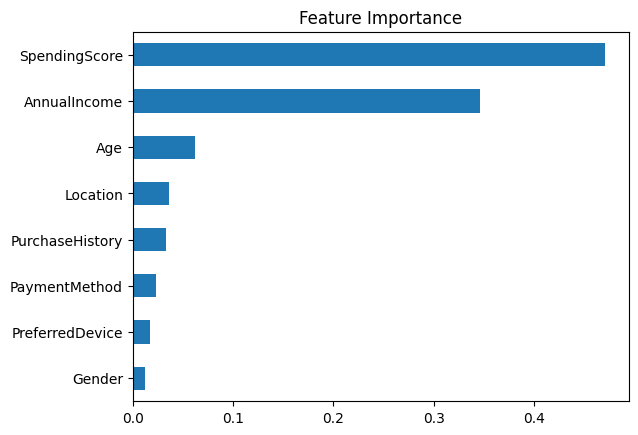

In [27]:
#12. Feature Importance (Random Forest)
feature_importances = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
)

feature_importances.sort_values().plot(kind='barh')

plt.title("Feature Importance")
plt.show()

In [32]:
#13. Model Comparison Table
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [log_accuracy, rf_accuracy]
})

print(results)

                 Model  Accuracy
0  Logistic Regression      0.64
1        Random Forest      0.97


In [33]:
#14. Key Insights for FastBuy
print("Key Insights:")

print("1. Random Forest generally performs better for segmentation tasks.")

print("2. Spending Score and Annual Income are major predictors of customer segment.")

print("3. Payment Method and Preferred Device also influence spending behaviour.")

Key Insights:
1. Random Forest generally performs better for segmentation tasks.
2. Spending Score and Annual Income are major predictors of customer segment.
3. Payment Method and Preferred Device also influence spending behaviour.


In [31]:
#15. Conclusion
print("Conclusion:")

print("The machine learning models successfully classify customers into Budget, Standard, and Premium segments.")

print("Automating segmentation will improve marketing targeting and operational efficiency for FastBuy.")

Conclusion:
The machine learning models successfully classify customers into Budget, Standard, and Premium segments.
Automating segmentation will improve marketing targeting and operational efficiency for FastBuy.
